# VAEの実装

In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms

In [6]:
# ハイパーパラメータの設定
input_dim = 784
hidden_dim = 200
latent_dim = 20
epochs = 30
learning_rate = 3e-4
batch_size = 32

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.linear_mu = nn.Linear(hidden_dim, latent_dim)
        self.linear_logvar = nn.Linear(hidden_dim, latent_dim)  #　標準偏差が0以上であることを満たすようにするため

    def forward(self, x):
        h = self.linear(x)
        h = F.relu(h)
        mu = self.linear_mu(h)
        logvar = self.linear_logvar(h)
        sigma = torch.exp(0.5*logvar)
        return mu, sigma
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = self.linear1(z)
        h = F.relu(h)
        h = self.linear2(h)
        x_hat = F.sigmoid(h)  # MNIST画像は0.0～1.0間のデータであるため
        return x_hat


In [8]:
def reparameterize(mu, sigma):
    eps = torch.rand_like(sigma)
    z = mu + eps * sigma
    return z


class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def get_loss(self, x):
        mu, sigma = self.encoder(x)
        z = reparameterize(mu, sigma)
        x_hat = self.decoder(z)

        batch_size = len(x)
        L1 = F.mse_loss(x_hat, x, reduction='sum')
        L2 = - torch.sum(1+torch.log(sigma ** 2) - mu**2 - sigma**2)
        return (L1 + L2) / batch_size

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(torch.flatten)
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)


In [10]:
model = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
losses = []

for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0
    for x, label in dataloader:
        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1
    
    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(loss_avg)


40.17151980489095
28.918589633178712
26.828581837972006
25.79927443745931
25.087424970499676
24.54221195373535
24.094297354125978
23.70496634724935
23.378451737467447
23.12738998819987
22.876937064615884
22.68338942159017
22.507547767130532
22.370502700805662
22.24822189737956
22.137744642130535
22.044703667195638
21.949385803222658
21.86029597269694
21.795014252726236
21.729114389038084
21.680710786946616
21.646376762898765
21.59099252726237
21.529695794677735
21.502822365315755
21.45347781270345
21.41028514404297
21.37480949503581
21.328506407674155


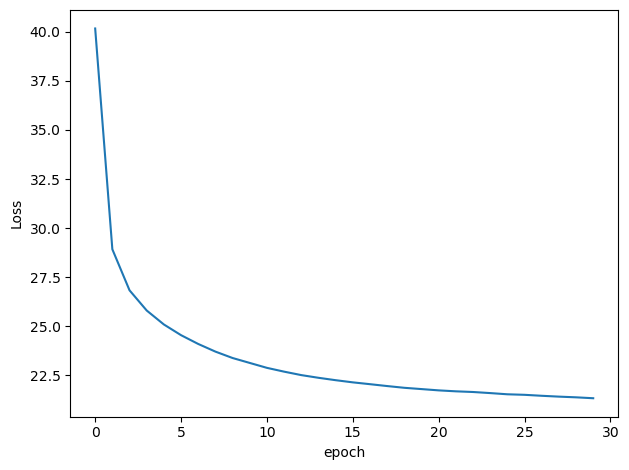

In [11]:
fig, ax = plt.subplots()

ax.plot(losses)
ax.set_xlabel("epoch")
ax.set_ylabel("Loss")

fig.tight_layout()
plt.show()

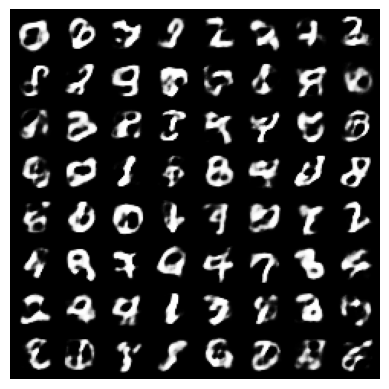

In [14]:
with torch.no_grad():
    sample_size = 64
    z = torch.randn(sample_size, latent_dim)
    x = model.decoder(z)
    generated_images = x.view(sample_size,1,28,28)

grid_img = torchvision.utils.make_grid(
    generated_images,
    nrow=8,
    padding=2,
    normalize=True
)

plt.imshow(grid_img.permute(1,2,0))
plt.axis("off")
plt.show()